In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:

df = pd.read_csv("GDPa1_v1.2_20250814.csv")
df

,antibody_id,antibody_name,Titer,Purity,SEC %Monomer,SMAC,HIC,HAC,PR_CHO,PR_Ova,...,hc_protein_sequence,hc_dna_sequence,vl_protein_sequence,lc_protein_sequence,lc_dna_sequence,hierarchical_cluster_fold,random_fold,hierarchical_cluster_IgG_isotype_stratified_fold,light_aligned_aho,heavy_aligned_aho
0,GDPa1-001,abagovomab,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,0.263108,...,MRAWIFFLLCLAGRALAQVKLQESGAELARPGASVKLSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,2,2,DIELTQSPASLSASVGETVTITCQAS--ENIY------SYLAWHQQ...,QVKLQES-GAELARPGASVKLSCKASG-YTFTN-----YWMQWVKQ...
1,GDPa1-002,abituzumab,193.31,99.825,97.620,2.745,2.545,3.690,0.205246,0.100155,...,MRAWIFFLLCLAGRALAQVQLQQSGGELAKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,4,0,DIQMTQSPSSLSASVGDRVTITCRAS--QDIS------NYLAWYQQ...,QVQLQQS-GGELAKPGASVKVSCKASG-YTFSS-----FWMHWVRQ...
2,GDPa1-003,abrezekimab,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,0.101180,...,MRAWIFFLLCLAGRALAQVTLKESGPVLVKPTETLTLTCTVSGFSL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,2,2,2,DIQMTQSPSSLSASVGDRVTITCLAS--EDIS------NYLAWYQQ...,QVTLKES-GPVLVKPTETLTLTCTVSG-FSLTN-----YHVQWIRQ...
3,GDPa1-004,abrilumab,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,0.054971,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKVSGYTL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSVSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,3,0,DIQMTQSPSSVSASVGDRVTITCRAS--QGIS------SWLAWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKVSG-YTLSD-----LSIHWVRQ...
4,GDPa1-005,adalimumab,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,0.085628,...,MRAWIFFLLCLAGRALAEVQLVESGGGLVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,2,0,DIQMTQSPSSLSASVGDRVTITCRAS--QGIR------NYLAWYQQ...,EVQLVES-GGGLVQPGRSLRLSCAASG-FTFDD-----YAMHWVRQ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,GDPa1-242,visilizumab,303.51,94.700,98.110,2.745,2.495,4.270,0.337537,0.338022,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCSASSSVSYMNWYQQKPGKAPKRL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCSASSSV...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,1,0,DIQMTQSPSSLSASVGDRVTITCSAS--SSVS-------YMNWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKASG-YTFIS-----YTMHWVRQ...
242,GDPa1-243,xentuzumab,281.21,98.970,99.875,10.000,4.500,NaN,0.178788,0.117684,...,MRAWIFFLLCLAGRALAQVELVESGGGLVQPGGSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIVLTQPPSVSGAPGQRVTISCSGSSSNIGSNSVSWYQQLPGTAPK...,MRAWIFFLLCLAGRALADIVLTQPPSVSGAPGQRVTISCSGSSSNI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,4,4,4,DIVLTQP-PSVSGAPGQRVTISCSGSS-SNIGS-----NSVSWYQQ...,QVELVES-GGGLVQPGGSLRLSCAASG-FTFTS-----YWMSWVRQ...
243,GDPa1-244,zalutumumab,266.55,89.430,98.065,2.705,2.590,3.760,0.000000,0.018385,...,MRAWIFFLLCLAGRALAQVQLVESGGGVVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,AIQLTQSPSSLSASVGDRVTITCRASQDISSALVWYQQKPGKAPKL...,MRAWIFFLLCLAGRALAAIQLTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,0,0,AIQLTQSPSSLSASVGDRVTITCRAS--QDIS------SALVWYQQ...,QVQLVES-GGGVVQPGRSLRLSCAASG-FTFST-----YGMHWVRQ...
244,GDPa1-245,zanolimumab,301.96,99.115,97.780,2.725,2.660,3.730,0.400486,0.100804,...,MRAWI

Antibody isotypes can strongly influence some of the developability metrics, so they must be included as a feature in the model.

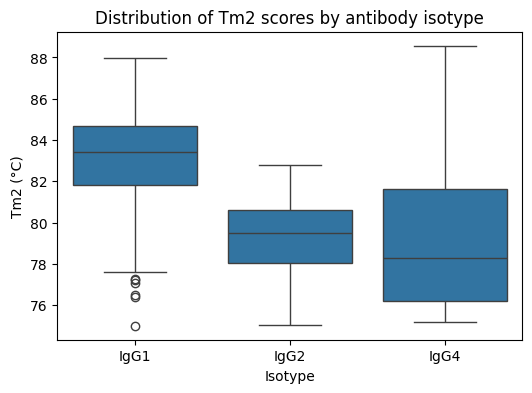

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = "Tm2")
plt.title("Distribution of Tm2 scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Tm2 (°C)")
plt.show()

In [5]:

print(df[["Titer", "HIC", "PR_CHO", "Tm2", 'AC-SINS_pH7.4']].isna().sum())
target = "HIC"

df = df.dropna(subset = [target])

Titer             7
HIC               4
PR_CHO           49
Tm2              53
AC-SINS_pH7.4     4
dtype: int64


In [6]:
model_name = "ollieturnbull/p-IgGen"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Paired sequence handling: Concatenate heavy and light chains and add beginning ("1") and end ("2") tokens
# (e.g. ["EVQLV...", "DIQMT..."] -> "1E V Q L V ... D I Q M T ... 2")
sequences = [
    "1" + " ".join(heavy) + " ".join(light) + "2"
    for heavy, light in zip(
        df["vh_protein_sequence"],
        df["vl_protein_sequence"],
    )
]

print(sequences[0])

config.json:   0%|          | 0.00/719 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

1Q V K L Q E S G A E L A R P G A S V K L S C K A S G Y T F T N Y W M Q W V K Q R P G Q G L D W I G A I Y P G D G N T R Y T H K F K G K A T L T A D K S S S T A Y M Q L S S L A S E D S G V Y Y C A R G E G N Y A W F A Y W G Q G T T V T V S SD I E L T Q S P A S L S A S V G E T V T I T C Q A S E N I Y S Y L A W H Q Q K Q G K S P Q L L V Y N A K T L A G G V S S R F S G S G S G T H F S L K I K S L Q P E D F G I Y Y C Q H H Y G I L P T F G G G T K L E I K2


In [7]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

batch_size = 16
mean_pooled_embeddings = []

for i in tqdm(range(0, len(sequences), batch_size)):
    batch = tokenizer(sequences[i:i+batch_size], return_tensors="pt", padding=True, truncation=True)
    outputs = model(batch["input_ids"].to(device), return_rep_layers=[-1], output_hidden_states=True)
    embeddings = outputs["hidden_states"][-1].detach().cpu().numpy()
    mean_pooled_embeddings.append(embeddings.mean(axis=1))

mean_pooled_embeddings = np.concatenate(mean_pooled_embeddings)

model.safetensors:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

  0%|          | 0/16 [00:00<?, ?it/s]

In [8]:
X = mean_pooled_embeddings
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lm = Ridge()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

SignificanceResult(statistic=np.float64(0.41341124897148246), pvalue=np.float64(0.0031521527808128337))


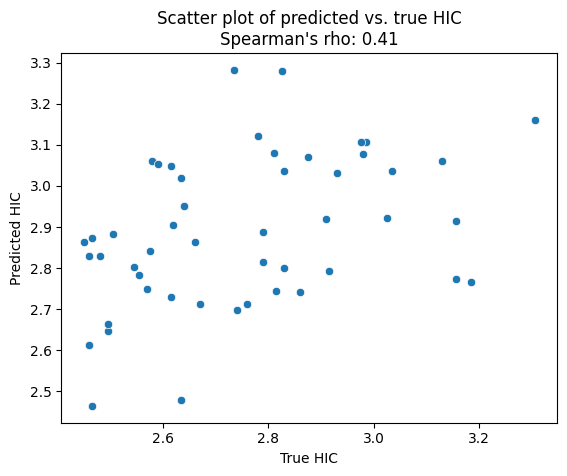

In [9]:
print(spearmanr(y_pred, y_test))

sns.scatterplot(x=y_test, y=y_pred)
plt.title(f"Scatter plot of predicted vs. true {target}\nSpearman's rho: {spearmanr(y_pred, y_test)[0]:.2f}")
plt.xlabel(f"True {target}")
plt.ylabel(f"Predicted {target}")
plt.show()

Fold	N	Spearman_rho
0	53	0.0810
1	48	0.2882
2	48	0.4557
3	44	0.4333
4	49	0.4089
Overall (all folds)	242	0.3241


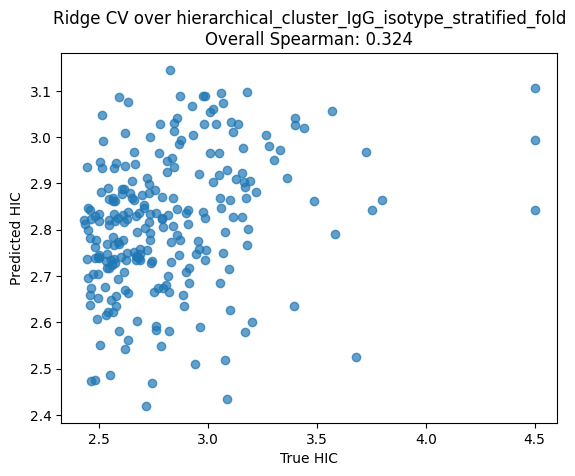

In [10]:
fold_col = "hierarchical_cluster_IgG_isotype_stratified_fold"
X = mean_pooled_embeddings
y = df[target].to_numpy(dtype=float)

# sanity check
assert len(X) == len(df) == len(y)

fold_values = df[fold_col].to_numpy()
unique_folds = [f for f in np.unique(fold_values) if f == f]  # drop NaN

per_fold_stats = []
y_pred_all = np.full(len(df), np.nan)   # align with df rows
y_true_all = np.full(len(df), np.nan)   # optional, for plotting/metrics

for f in unique_folds:
    test_idx = np.where(fold_values == f)[0]
    train_idx = np.where(fold_values != f)[0]

    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    lm = Ridge()
    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)

    # write back into the positions of df
    y_pred_all[test_idx] = y_pred
    y_true_all[test_idx] = y_test

    rho = spearmanr(y_test, y_pred).statistic
    per_fold_stats.append((int(f), rho, len(y_test)))

# Overall metric across all rows that participated in CV
mask = ~np.isnan(y_true_all)
overall_rho = spearmanr(y_true_all[mask], y_pred_all[mask]).statistic

print("Fold\tN\tSpearman_rho")
for f, rho, n in per_fold_stats:
    print(f"{f}\t{n}\t{rho:.4f}")
print(f"Overall (all folds)\t{mask.sum()}\t{overall_rho:.4f}")

plt.figure()
plt.scatter(y_true_all[mask], y_pred_all[mask], alpha=0.7)
plt.title(f"Ridge CV over {fold_col}\nOverall Spearman: {overall_rho:.3f}")
plt.xlabel(f"True {target}")
plt.ylabel(f"Predicted {target}")
plt.show()
